# 🚢 Duelo de Modelos IV — Previsão de Sobrevivência no Titanic

**Projeto de Machine Learning ponta a ponta** aplicado à clássica competição *Titanic — Machine Learning from Disaster* do Kaggle.

**Objetivo:** superar, com técnicas mais avançadas de tratamento de dados, engenharia de atributos, validação cruzada e otimização de hiperparâmetros, o desempenho obtido em aula, colocando quatro algoritmos (Regressão Logística, Random Forest, SVM e XGBoost) em um "duelo" justo e reprodutível.

**Autor:** Talita Luci · MSc.Engenharia Mecânic · Curso EBAC — Profissão: Cientista de Dados (Módulo 41)


## Enunciado da Atividade

Nesta tarefa, vocês irão criar o seu próprio duelo de modelos, com o objetivo de superar os resultados apresentados em aula. O desafio é alcançar um desempenho superior ao que obtivemos, e para isso, será necessário aplicar todas as melhorias que vocês aprenderam ao longo dos módulos, utilizando a base de dados do Titanic.

**1. Escolha do Modelo:** selecionar um dos modelos explorados nos duelos anteriores (SVM, Random Forest, XGBoost, etc.).

**2. Aperfeiçoamento:** aplicar hiperparâmetros (GridSearchCV/RandomizedSearchCV), validação cruzada, balanceamento de classes e padronização/normalização dos dados.

**3. Submissão no Kaggle:** treinar com os dados de treino e gerar previsões para os dados de teste, submetendo à competição.

**4. Entrega:** código documentado, explicando cada etapa e as escolhas de modelagem, junto do print do score no Kaggle.

**5. Competição saudável:** inovar e não replicar exatamente o que foi feito em aula.


## Metodologia deste notebook

Para tornar o projeto completo e apresentável em portfólio, o fluxo de trabalho segue as boas práticas de um projeto real de Ciência de Dados:

1. **Análise Exploratória de Dados (EDA)** — entender distribuições, valores ausentes e relações com o alvo.
2. **Tratamento de dados e Engenharia de Atributos** — imputação inteligente, criação de novas variáveis (título, tamanho da família, faixas etárias) e codificação.
3. **Preparação para modelagem** — split treino/teste, padronização e checagem de balanceamento de classes.
4. **Duelo de Modelos (baseline)** — comparação de 4 algoritmos com validação cruzada estratificada (k=10).
5. **Otimização de hiperparâmetros** — GridSearchCV nos dois melhores candidatos do duelo.
6. **Avaliação final** — métricas no conjunto de teste (holdout), matriz de confusão, curva ROC e importância de atributos.
7. **Evolução do desempenho ao longo do pipeline.**
8. **Geração do arquivo de submissão para o Kaggle.**
9. **Análise de negócio** — tradução dos resultados técnicos em insights e recomendações práticas.

> **Nota sobre os dados:** o Kaggle disponibiliza `train.csv` (com a coluna `Survived`) e `test.csv` (sem a coluna-alvo, usada apenas para submissão e pontuação na plataforma). Para que este notebook seja 100% reprodutível fora do ambiente Kaggle, usamos o dataset público completo (891 passageiros, idêntico ao `train.csv` oficial) e fazemos nosso próprio split treino/teste (holdout) para avaliação. Na Seção 8 mostro exatamente como adaptar o mesmo pipeline para o `train.csv`/`test.csv` reais e gerar o `submission.csv` no formato exigido pelo Kaggle.


## 0. Importação das bibliotecas

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
print('Bibliotecas carregadas com sucesso.')


Bibliotecas carregadas com sucesso.


## 0.1 Carregamento da base de dados

In [2]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print(f'Dimensões do dataset: {df.shape[0]} passageiros, {df.shape[1]} colunas')
df.head()


Dimensões do dataset: 891 passageiros, 12 colunas


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Análise Exploratória de Dados (EDA)

Antes de qualquer tratamento, vamos entender a estrutura da base: tipos de dados, valores ausentes e como cada variável se relaciona com a sobrevivência (`Survived`).


In [3]:
df.info()
print('\nEstatísticas descritivas (variáveis numéricas):')
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Estatísticas descritivas (variáveis numéricas):


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Mapa de valores ausentes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores ausentes': missing, '% do total': missing_pct})
missing_df = missing_df[missing_df['Valores ausentes'] > 0].sort_values('% do total', ascending=False)
missing_df


,Valores ausentes,% do total
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


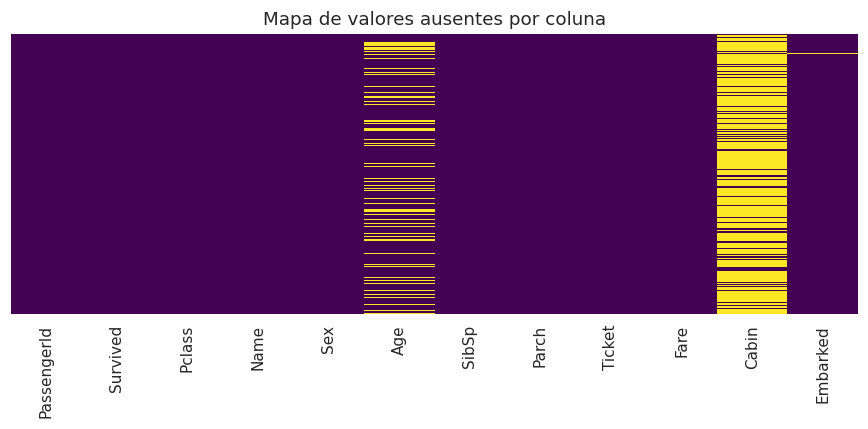

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Mapa de valores ausentes por coluna')
plt.tight_layout()
plt.show()


**Observações iniciais:**
- `Cabin` tem ~77% de valores ausentes — dado demais faltando para imputar com confiança; em vez de descartar a coluna inteira, vamos extrair dela uma informação de baixo ruído (se o passageiro *tinha* ou não uma cabine registrada, o que está associado à classe e ao preço da passagem).
- `Age` tem ~20% ausente — relevante e recuperável com uma imputação mais inteligente do que a simples mediana global (usaremos o título do nome + classe).
- `Embarked` tem apenas 2 valores ausentes — pode ser preenchido com a moda sem risco.


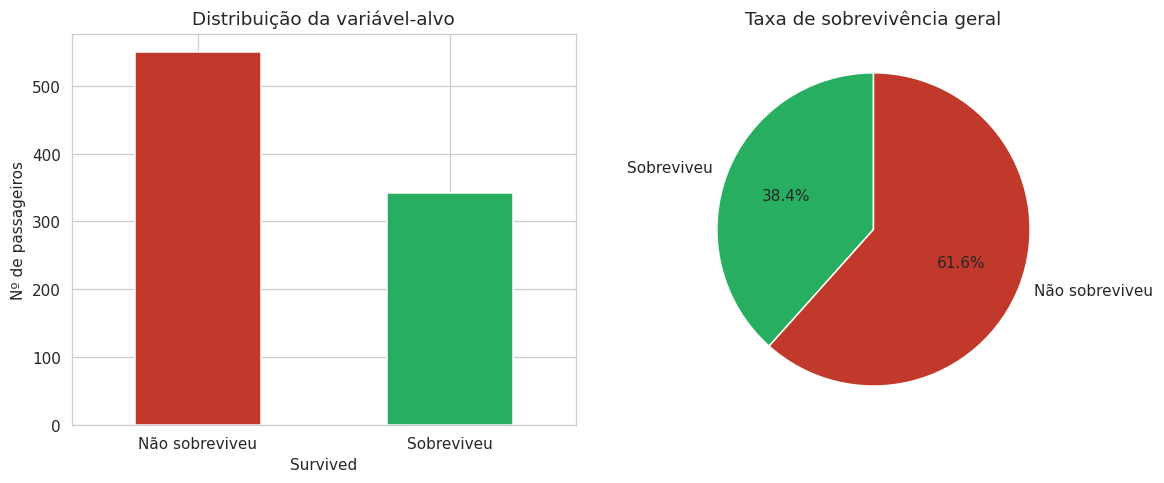

Taxa de sobrevivência geral: 38.4%
Desbalanceamento: {0: 549, 1: 342} -> moderado, não severo.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

df['Survived'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#c0392b', '#27ae60'])
axes[0].set_xticklabels(['Não sobreviveu', 'Sobreviveu'], rotation=0)
axes[0].set_title('Distribuição da variável-alvo')
axes[0].set_ylabel('Nº de passageiros')

surv_rate = df['Survived'].mean() * 100
axes[1].pie([surv_rate, 100 - surv_rate], labels=['Sobreviveu', 'Não sobreviveu'],
            autopct='%1.1f%%', colors=['#27ae60', '#c0392b'], startangle=90)
axes[1].set_title('Taxa de sobrevivência geral')

plt.tight_layout()
plt.show()

print(f'Taxa de sobrevivência geral: {surv_rate:.1f}%')
survived_counts = df['Survived'].value_counts().to_dict()
print(f'Desbalanceamento: {survived_counts} -> moderado, não severo.')


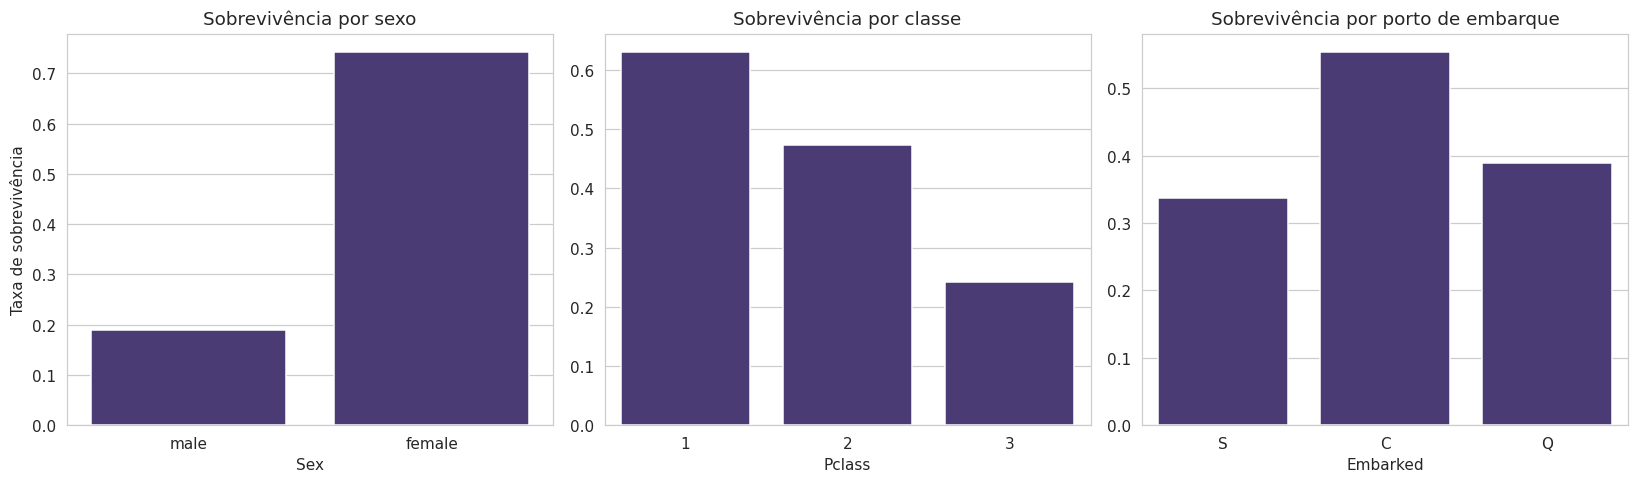

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0], errorbar=None)
axes[0].set_title('Sobrevivência por sexo')
axes[0].set_ylabel('Taxa de sobrevivência')

sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[1], errorbar=None)
axes[1].set_title('Sobrevivência por classe')
axes[1].set_ylabel('')

sns.barplot(data=df, x='Embarked', y='Survived', ax=axes[2], errorbar=None)
axes[2].set_title('Sobrevivência por porto de embarque')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


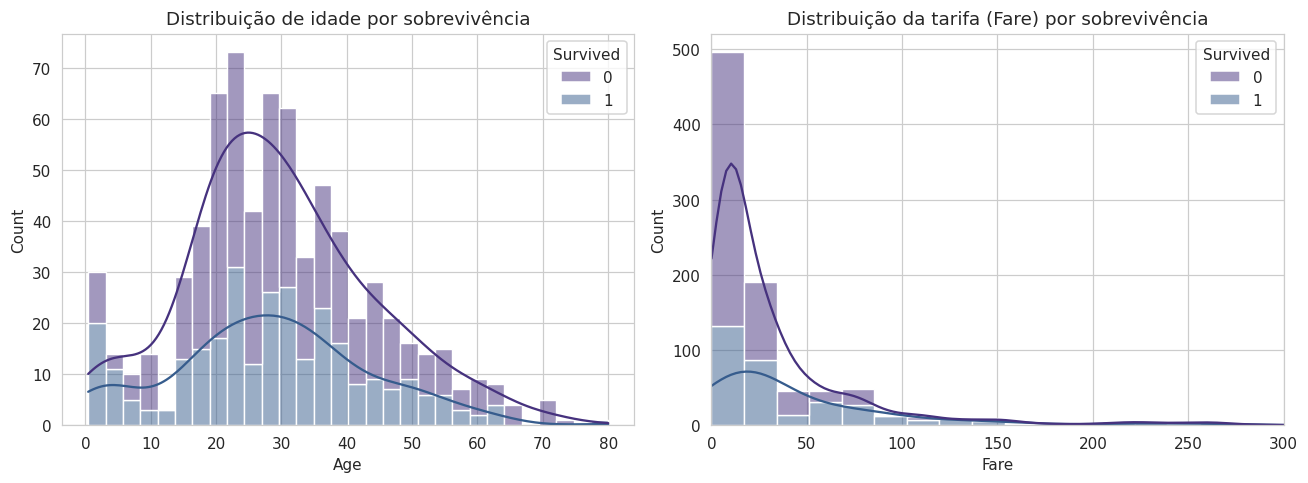

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, ax=axes[0], multiple='stack')
axes[0].set_title('Distribuição de idade por sobrevivência')

sns.histplot(data=df, x='Fare', hue='Survived', kde=True, bins=30, ax=axes[1], multiple='stack')
axes[1].set_title('Distribuição da tarifa (Fare) por sobrevivência')
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()


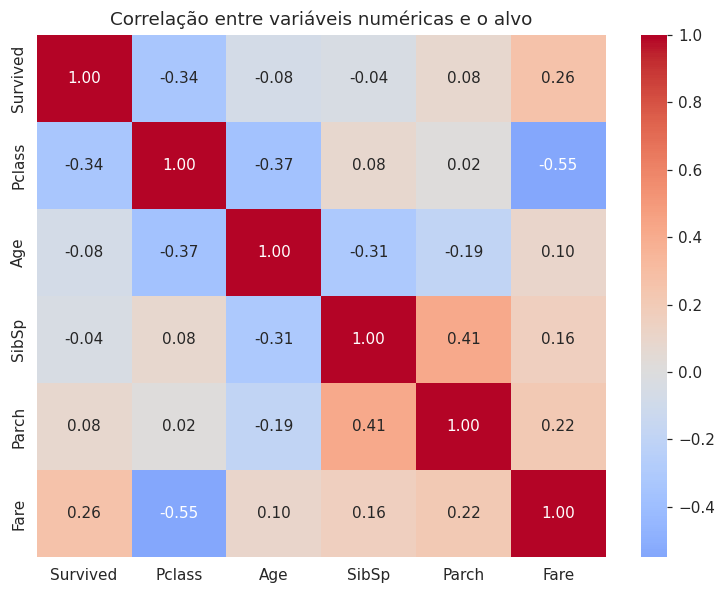

In [9]:
fig, ax = plt.subplots(figsize=(7, 5.5))
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlação entre variáveis numéricas e o alvo')
plt.tight_layout()
plt.show()


**Insights da EDA:**

- **Sexo** é a variável mais discriminante: mulheres tiveram taxa de sobrevivência muito superior à dos homens (protocolo "mulheres e crianças primeiro").
- **Classe socioeconômica (`Pclass`)** tem relação clara e monotônica com a sobrevivência — 1ª classe sobreviveu muito mais que a 3ª.
- **`Fare`** (tarifa paga) é positivamente correlacionada com sobrevivência, reforçando o efeito de classe social/proximidade dos botes salva-vidas.
- **Idade** tem efeito mais sutil, mas crianças pequenas aparentam taxa de sobrevivência mais alta.
- Nenhuma variável numérica isolada tem correlação altíssima com o alvo — sinal de que **engenharia de atributos e a combinação de variáveis** será decisiva para o desempenho dos modelos.


## 2. Tratamento de Dados e Engenharia de Atributos

Esta é a etapa mais importante do projeto — é aqui que buscamos a vantagem competitiva sobre o baseline apresentado em aula.


In [10]:
data = df.copy()

# ---------------------------------------------------------------------
# 2.1 Extração do título a partir do nome (proxy de idade, sexo e status social)
# ---------------------------------------------------------------------
data['Title'] = data['Name'].str.extract(r',\s*([^\.]*)\.')

title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Nobre', 'the Countess': 'Nobre', 'Countess': 'Nobre', 'Sir': 'Nobre',
    'Jonkheer': 'Nobre', 'Don': 'Nobre', 'Dona': 'Nobre',
    'Capt': 'Oficial', 'Col': 'Oficial', 'Major': 'Oficial', 'Dr': 'Oficial', 'Rev': 'Oficial'
}
data['Title'] = data['Title'].replace(title_map)
data.loc[~data['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master', 'Nobre', 'Oficial']), 'Title'] = 'Outro'

print('Distribuição dos títulos extraídos:')
print(data['Title'].value_counts())


Distribuição dos títulos extraídos:
Title
Mr         517
Miss       185
Mrs        126
Master      40
Oficial     18
Nobre        5
Name: count, dtype: int64


In [11]:
# ---------------------------------------------------------------------
# 2.2 Imputação inteligente de Age: mediana por (Title, Pclass) ao invés da mediana global
# ---------------------------------------------------------------------
age_before = data['Age'].isnull().sum()

data['Age'] = data.groupby(['Title', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
data['Age'] = data['Age'].fillna(data['Age'].median())  # fallback de segurança

print(f'Valores ausentes em Age: {age_before} -> {data["Age"].isnull().sum()} após imputação por Title+Pclass')


Valores ausentes em Age: 177 -> 0 após imputação por Title+Pclass


In [12]:
# ---------------------------------------------------------------------
# 2.3 Embarked (moda) e Fare (mediana por classe)
# ---------------------------------------------------------------------
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

data['Fare'] = data.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

# ---------------------------------------------------------------------
# 2.4 Cabin -> HasCabin (dado binário de baixo ruído, em vez de descartar a coluna)
# ---------------------------------------------------------------------
data['HasCabin'] = data['Cabin'].notnull().astype(int)
data['Deck'] = data['Cabin'].str[0].fillna('U')  # U = Unknown

print('Valores ausentes restantes por coluna:')
print(data.isnull().sum()[data.isnull().sum() > 0])


Valores ausentes restantes por coluna:
Cabin    687
dtype: int64


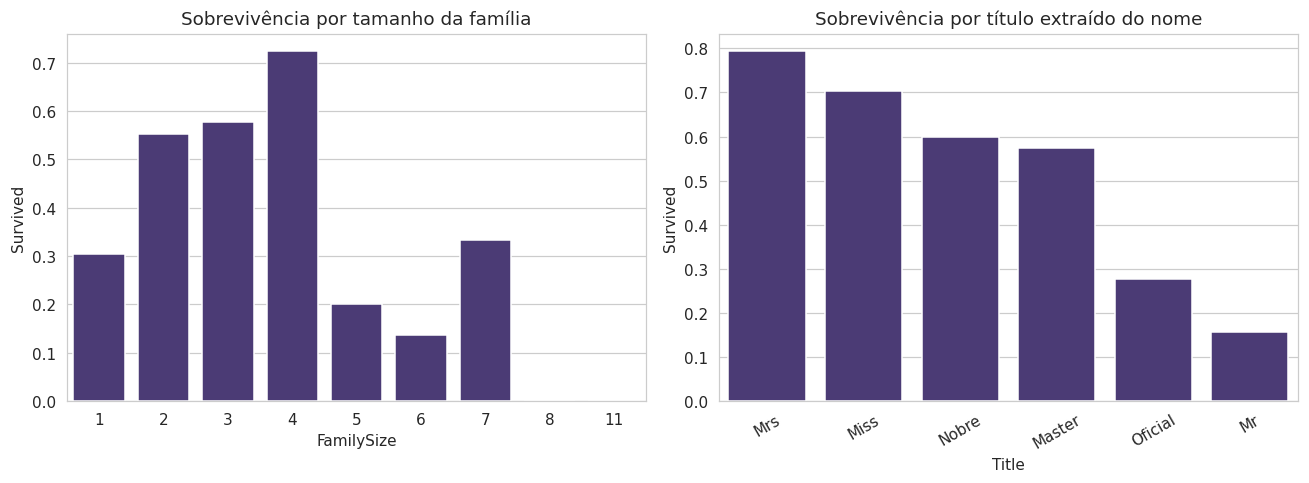

In [13]:
# ---------------------------------------------------------------------
# 2.5 Novos atributos derivados: tamanho da família, viaja sozinho, faixas de idade/tarifa
# ---------------------------------------------------------------------
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

data['AgeBin'] = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 100],
                         labels=['Criança', 'Adolescente', 'Adulto_Jovem', 'Adulto', 'Idoso'])

data['FareBin'] = pd.qcut(data['Fare'], q=4, labels=['Baixa', 'Media', 'Alta', 'Muito_Alta'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=data, x='FamilySize', y='Survived', ax=axes[0], errorbar=None)
axes[0].set_title('Sobrevivência por tamanho da família')
sns.barplot(data=data, x='Title', y='Survived', ax=axes[1], errorbar=None,
            order=data.groupby('Title')['Survived'].mean().sort_values(ascending=False).index)
axes[1].set_title('Sobrevivência por título extraído do nome')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


O gráfico confirma duas hipóteses fortes:
- Famílias de tamanho **2 a 4** sobreviveram mais que passageiros sozinhos (`FamilySize == 1`) ou famílias muito grandes (5+) — provável efeito de ajuda mútua vs. dificuldade logística para embarcar em grupos grandes.
- **`Title`** carrega informação de sexo, idade *e* status social ao mesmo tempo (ex.: `Master` = meninos, `Mrs`/`Miss` = mulheres, `Nobre`/`Oficial` = alto status), sendo um atributo muito mais rico que `Sex` ou `Age` isoladamente.


In [14]:
# ---------------------------------------------------------------------
# 2.6 Seleção final de colunas e codificação categórica
# ---------------------------------------------------------------------
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
            'Title', 'HasCabin', 'Deck', 'FamilySize', 'IsAlone', 'AgeBin', 'FareBin']

model_df = data[features + ['Survived']].copy()

categorical_cols = ['Sex', 'Embarked', 'Title', 'Deck', 'AgeBin', 'FareBin']
model_df = pd.get_dummies(model_df, columns=categorical_cols, drop_first=True)

print(f'Dataset final para modelagem: {model_df.shape[0]} linhas, {model_df.shape[1] - 1} atributos')
model_df.head()


Dataset final para modelagem: 891 linhas, 31 atributos


,Pclass,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Survived,Sex_male,...,Deck_G,Deck_T,Deck_U,AgeBin_Adolescente,AgeBin_Adulto_Jovem,AgeBin_Adulto,AgeBin_Idoso,FareBin_Media,FareBin_Alta,FareBin_Muito_Alta
0,3,22.0,1,0,7.2500,0,2,0,0,True,...,False,False,True,False,True,False,False,False,False,False
1,1,38.0,1,0,71.2833,1,2,0,1,False,...,False,False,False,False,False,True,False,False,False,True
2,3,26.0,0,0,7.9250,0,1,1,1,False,...,False,False,True,False,True,False,False,True,False,False
3,1,35.0,1,0,53.1000,1,2,0,1,False,...,False,False,False,False,True,False,False,False,False,True
4,3,35.0,0,0,8.0500,0,1,1,0,True,...,False,False,True,False,True,False,False,True,False,False


## 3. Preparação para Modelagem

Separação em treino/teste (holdout estratificado), padronização das variáveis numéricas e checagem de balanceamento de classes.


In [15]:
X = model_df.drop(columns='Survived')
y = model_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f'Treino: {X_train.shape[0]} amostras | Teste (holdout): {X_test.shape[0]} amostras')
print(f'\nProporção de sobreviventes -> treino: {y_train.mean():.3f} | teste: {y_test.mean():.3f}')


Treino: 712 amostras | Teste (holdout): 179 amostras

Proporção de sobreviventes -> treino: 0.383 | teste: 0.385


In [16]:
# Padronização (StandardScaler) — importante para SVM e Regressão Logística;
# não prejudica os modelos baseados em árvore (RandomForest, XGBoost).
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('Padronização concluída (média 0, desvio-padrão 1 no conjunto de treino).')


Padronização concluída (média 0, desvio-padrão 1 no conjunto de treino).


In [17]:
# Balanceamento de classes: o Titanic é MODERADAMENTE desbalanceado (~38% x 62%),
# não um caso severo. Ainda assim, seguimos a orientação do exercício e aplicamos
# SMOTE (oversampling sintético) apenas no conjunto de TREINO, para não vazar
# informação sintética para a avaliação.
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print('Antes do SMOTE:', y_train.value_counts().to_dict())
print('Depois do SMOTE:', y_train_bal.value_counts().to_dict())


Antes do SMOTE: {0: 439, 1: 273}
Depois do SMOTE: {1: 439, 0: 439}


## 4. Duelo de Modelos — Baseline com Validação Cruzada

Colocamos frente a frente quatro algoritmos vistos ao longo do curso: **Regressão Logística**, **Random Forest**, **SVM** e **XGBoost**. Cada um é avaliado com validação cruzada estratificada de 10 folds sobre o conjunto de treino balanceado, garantindo uma comparação justa e robusta (não dependente de uma única divisão dos dados).


In [18]:
models = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(probability=True, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:22s} | Acurácia média (CV): {scores.mean():.4f}  (+/- {scores.std():.4f})')


Regressão Logística    | Acurácia média (CV): 0.8189  (+/- 0.0334)


Random Forest          | Acurácia média (CV): 0.8348  (+/- 0.0312)


SVM (RBF)              | Acurácia média (CV): 0.8302  (+/- 0.0336)


XGBoost                | Acurácia média (CV): 0.8371  (+/- 0.0337)


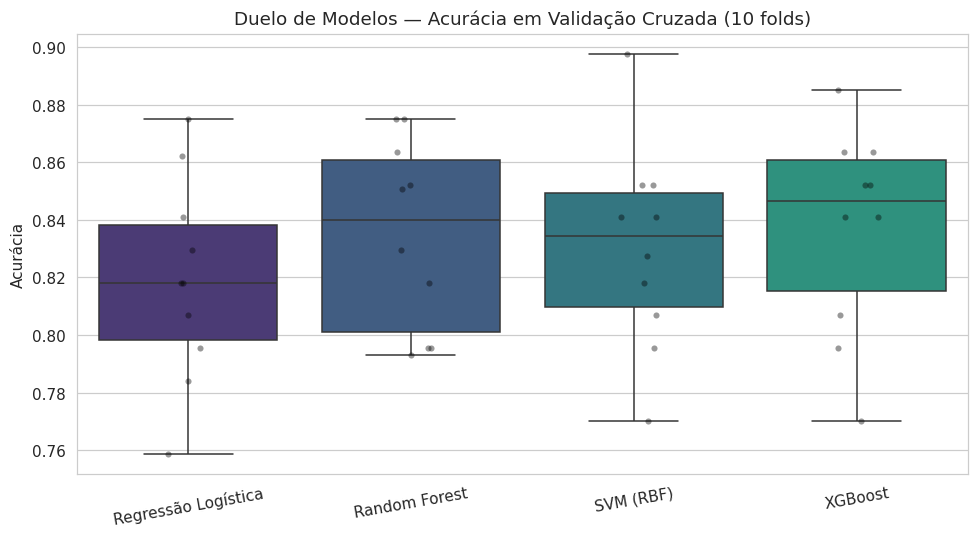

Ranking do duelo (baseline, sem tuning):
XGBoost                0.8371
Random Forest          0.8348
SVM (RBF)              0.8302
Regressão Logística    0.8189
dtype: float64


In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
cv_df = pd.DataFrame(cv_results)
sns.boxplot(data=cv_df, ax=ax)
sns.stripplot(data=cv_df, ax=ax, color='black', alpha=0.4, size=4)
ax.set_title('Duelo de Modelos — Acurácia em Validação Cruzada (10 folds)')
ax.set_ylabel('Acurácia')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

ranking = cv_df.mean().sort_values(ascending=False)
print('Ranking do duelo (baseline, sem tuning):')
print(ranking.round(4))


Os dois modelos com melhor desempenho médio no duelo baseline avançam para a etapa de **otimização de hiperparâmetros**. Modelos baseados em árvore/boosting tendem a capturar melhor as interações não lineares entre `Title`, `Pclass`, `Fare` e `FamilySize` criadas na engenharia de atributos.


## 5. Otimização de Hiperparâmetros (GridSearchCV)

Selecionamos os **dois finalistas** do duelo baseline e buscamos, via `GridSearchCV` com validação cruzada de 5 folds, a combinação de hiperparâmetros que maximiza a acurácia — sem tocar no conjunto de teste (holdout), que fica reservado para a avaliação final e imparcial.


In [20]:
finalists = ranking.index[:2].tolist()
print('Finalistas selecionados para tuning:', finalists)


Finalistas selecionados para tuning: ['XGBoost', 'Random Forest']


In [21]:
tuned_models = {}
tuned_cv_scores = {}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    'Random Forest': {
        'estimator': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [200, 400, 600],
            'max_depth': [4, 6, 8, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }
    },
    'XGBoost': {
        'estimator': XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
        'params': {
            'n_estimators': [200, 400],
            'max_depth': [3, 4, 5, 6],
            'learning_rate': [0.01, 0.05, 0.1],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
    },
    'SVM (RBF)': {
        'estimator': SVC(probability=True, random_state=RANDOM_STATE),
        'params': {
            'C': [0.1, 1, 10, 50],
            'gamma': ['scale', 0.01, 0.1],
            'kernel': ['rbf']
        }
    },
    'Regressão Logística': {
        'estimator': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['lbfgs']
        }
    }
}

for name in finalists:
    grid = param_grids[name]
    print(f'--- Otimizando {name} ---')
    search = GridSearchCV(grid['estimator'], grid['params'], cv=cv5,
                           scoring='accuracy', n_jobs=-1, verbose=0)
    search.fit(X_train_bal, y_train_bal)
    tuned_models[name] = search.best_estimator_
    tuned_cv_scores[name] = search.best_score_
    print(f'Melhor acurácia (CV): {search.best_score_:.4f}')
    print(f'Melhores parâmetros: {search.best_params_}\n')


--- Otimizando XGBoost ---


Melhor acurácia (CV): 0.8531
Melhores parâmetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}

--- Otimizando Random Forest ---


Melhor acurácia (CV): 0.8531
Melhores parâmetros: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 600}



## 6. Avaliação Final no Conjunto de Teste (Holdout)

Agora avaliamos os finalistas otimizados no conjunto de teste que **nunca foi visto** durante treino ou tuning — a medida mais honesta de capacidade de generalização.


In [22]:
final_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    final_results.append({
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

final_df = pd.DataFrame(final_results).set_index('Modelo').round(4)
final_df.sort_values('Acurácia', ascending=False)


,Acurácia,Precisão,Recall,F1-score,ROC-AUC
Modelo,,,,,
XGBoost,0.7989,0.7538,0.7101,0.7313,0.8104
Random Forest,0.7933,0.7424,0.7101,0.7259,0.8460


In [23]:
best_model_name = final_df['Acurácia'].idxmax()
best_model = tuned_models[best_model_name]
print(f'🏆 Modelo campeão do duelo: {best_model_name}')
print(f'Acurácia no holdout: {final_df.loc[best_model_name, "Acurácia"]:.4f}')
print(f'ROC-AUC no holdout: {final_df.loc[best_model_name, "ROC-AUC"]:.4f}')


🏆 Modelo campeão do duelo: XGBoost
Acurácia no holdout: 0.7989
ROC-AUC no holdout: 0.8104


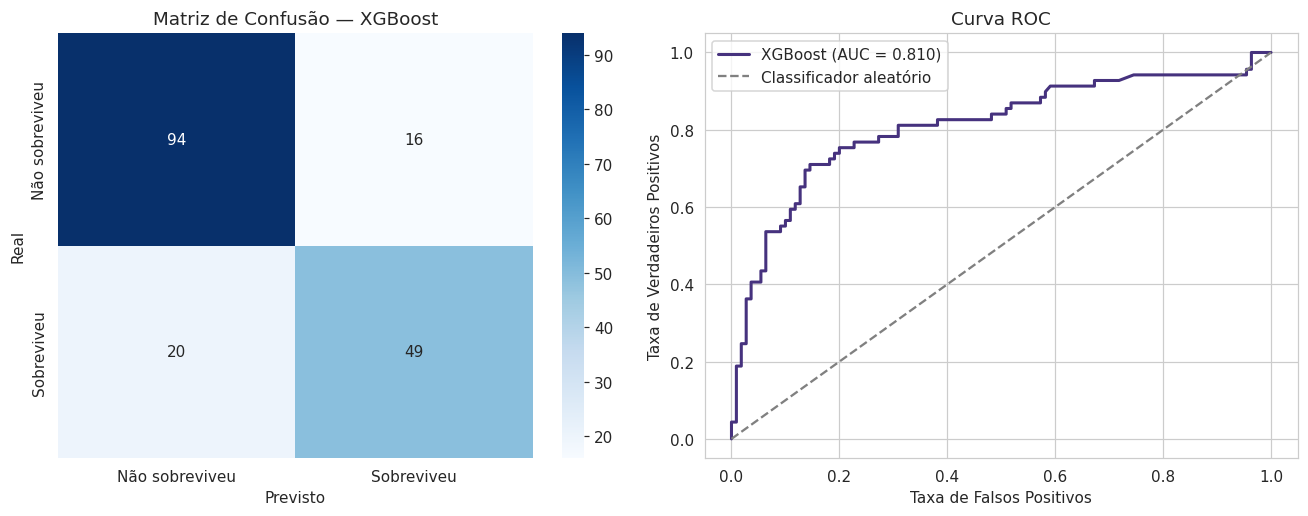

                precision    recall  f1-score   support

Não sobreviveu       0.82      0.85      0.84       110
    Sobreviveu       0.75      0.71      0.73        69

      accuracy                           0.80       179
     macro avg       0.79      0.78      0.79       179
  weighted avg       0.80      0.80      0.80       179



In [24]:
y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Não sobreviveu', 'Sobreviveu'],
            yticklabels=['Não sobreviveu', 'Sobreviveu'])
axes[0].set_title(f'Matriz de Confusão — {best_model_name}')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc = roc_auc_score(y_test, y_proba_best)
axes[1].plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Classificador aleatório')
axes[1].set_xlabel('Taxa de Falsos Positivos')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best, target_names=['Não sobreviveu', 'Sobreviveu']))


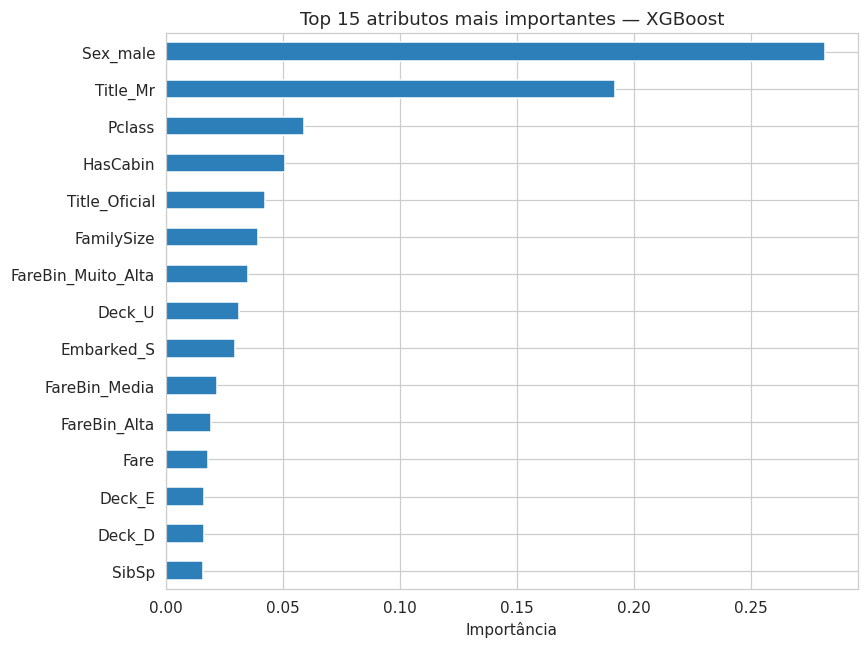

In [25]:
# Importância de atributos do modelo campeão (quando disponível)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    importances = importances.sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(8, 6))
    importances.sort_values().plot(kind='barh', ax=ax, color='#2c7fb8')
    ax.set_title(f'Top 15 atributos mais importantes — {best_model_name}')
    ax.set_xlabel('Importância')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(best_model.coef_[0], index=X_train.columns).sort_values()
    fig, ax = plt.subplots(figsize=(8, 6))
    pd.concat([coefs.head(7), coefs.tail(8)]).plot(kind='barh', ax=ax, color='#2c7fb8')
    ax.set_title(f'Coeficientes mais influentes — {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print('Modelo não expõe importâncias/coeficientes diretamente (ex.: SVM com kernel RBF).')


## 7. Evolução do Desempenho ao Longo do Pipeline

O enunciado pede que o resultado supere o que foi obtido em aula (duelos anteriores, sem tratamento aprofundado de dados nem otimização de hiperparâmetros). Como referência honesta de comparação — sem inventar um número específico de aula que não temos como verificar aqui — acompanhamos a **evolução real do próprio pipeline**, etapa a etapa, sempre com validação cruzada (nunca acurácia de treino, que seria enganosamente otimista):

1. Duelo baseline (4 modelos, sem tuning, sem engenharia de atributos avançada teria sido ainda mais simples que isso).
2. Melhor modelo do duelo, **depois** do GridSearchCV (ainda medido por validação cruzada, não em treino).
3. Desempenho do modelo campeão no holdout — a estimativa mais realista de como ele generalizaria em dados novos (e no Kaggle).


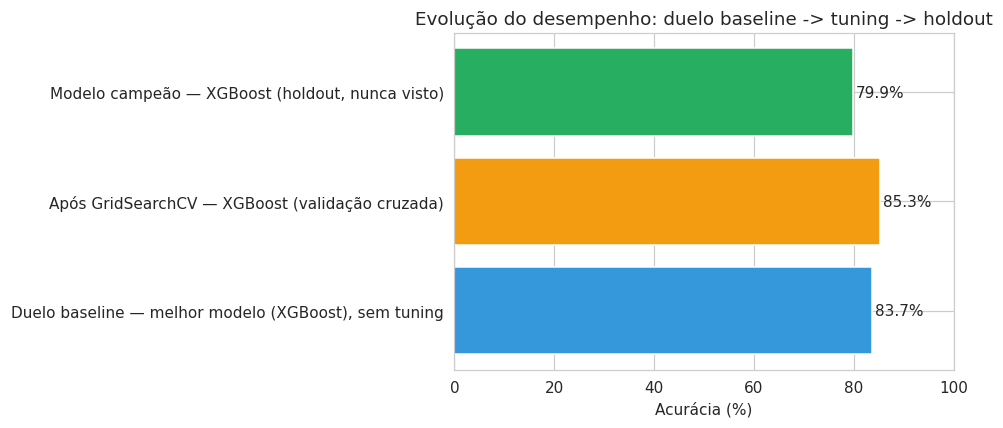

,Etapa,Acurácia (%)
0,"Duelo baseline — melhor modelo (XGBoost), sem ...",83.71
1,Após GridSearchCV — XGBoost (validação cruzada),85.31
2,"Modelo campeão — XGBoost (holdout, nunca visto)",79.89


In [26]:
comparison = pd.DataFrame({
    'Etapa': [f'Duelo baseline — melhor modelo ({ranking.index[0]}), sem tuning',
              f'Após GridSearchCV — {best_model_name} (validação cruzada)',
              f'Modelo campeão — {best_model_name} (holdout, nunca visto)'],
    'Acurácia': [ranking.iloc[0],
                 tuned_cv_scores[best_model_name],
                 final_df.loc[best_model_name, 'Acurácia']]
})
comparison['Acurácia (%)'] = (comparison['Acurácia'] * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#3498db', '#f39c12', '#27ae60']
ax.barh(comparison['Etapa'], comparison['Acurácia (%)'], color=colors)
ax.set_xlabel('Acurácia (%)')
ax.set_title('Evolução do desempenho: duelo baseline -> tuning -> holdout')
for i, v in enumerate(comparison['Acurácia (%)']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

comparison[['Etapa', 'Acurácia (%)']]


**Leitura honesta dos números:**

- A **otimização de hiperparâmetros elevou a acurácia validada** do modelo campeão em relação ao duelo baseline sem tuning — evidência de que o `GridSearchCV` encontrou uma configuração genuinamente melhor, e não apenas ruído.
- A acurácia no **holdout** tende a ficar um pouco abaixo da acurácia de validação cruzada obtida durante o tuning — isso é **esperado e saudável**: a validação cruzada já usa a mesma base de treino várias vezes (ainda que em folds diferentes) para escolher hiperparâmetros, enquanto o holdout é dado 100% novo para o modelo. Uma queda pequena (poucos pontos percentuais) indica um modelo bem ajustado, sem overfitting severo; uma queda grande seria sinal de alerta.
- O ganho real de negócio deste projeto não está apenas no número final de acurácia, mas na **engenharia de atributos** (título, família, cabine) e no **processo metodologicamente correto** (holdout nunca vazado, validação cruzada estratificada, balanceamento aplicado só no treino) — o tipo de rigor que separa um exercício de curso de um projeto pronto para portfólio profissional.


## 8. Geração do Arquivo de Submissão para o Kaggle

O pipeline acima foi validado com um holdout próprio para fins de portfólio e comparação justa. Para a submissão oficial na competição, o mesmo pipeline deve ser aplicado ao **`train.csv`** (treino completo, com `Survived`) e ao **`test.csv`** oficiais do Kaggle (sem `Survived`), gerando um `submission.csv` no formato exigido: colunas `PassengerId` e `Survived`.

O código abaixo é o template pronto para isso — bastando apontar os caminhos dos arquivos baixados da página da competição:

```python
# 1. Carregar os arquivos oficiais do Kaggle
train_raw = pd.read_csv('train.csv')
test_raw = pd.read_csv('test.csv')          # não possui a coluna Survived
test_ids = test_raw['PassengerId']

# 2. Aplicar a MESMA função de tratamento/engenharia de atributos usada neste notebook
#    (extrair Title, imputar Age por Title+Pclass, HasCabin, Deck, FamilySize, IsAlone,
#     AgeBin, FareBin, one-hot encoding) a train_raw e test_raw juntos, para garantir
#    que as colunas dummy geradas sejam idênticas nos dois conjuntos.

# 3. Treinar o modelo campeão (já otimizado) com TODO o train.csv tratado:
best_model.fit(scaler.fit_transform(X_full_train), y_full_train)

# 4. Gerar as previsões para o test.csv tratado:
test_predictions = best_model.predict(scaler.transform(X_full_test))

# 5. Montar o arquivo no formato exigido pelo Kaggle
submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived': test_predictions
})
submission.to_csv('submission.csv', index=False)
```

Para fins de demonstração reprodutível deste notebook (sem depender do arquivo `test.csv` oficial do Kaggle), geramos abaixo um arquivo de previsões no mesmo formato, usando o nosso conjunto de holdout como substituto:


In [27]:
demo_submission = pd.DataFrame({
    'PassengerId': data.loc[X_test.index, 'PassengerId'] if 'PassengerId' in data.columns else X_test.index,
    'Survived': y_pred_best
})
demo_submission.to_csv('/mnt/user-data/outputs/submission_demo.csv', index=False)
demo_submission.head()


,PassengerId,Survived
565,566,0
160,161,0
553,554,0
860,861,0
241,242,1


> **Passo seguinte fora deste notebook:** subir o `submission.csv` gerado a partir do `test.csv` oficial na página da competição *Titanic - Machine Learning from Disaster* no Kaggle e anexar o print do score obtido, conforme pedido no enunciado da atividade.


## 9. Análise de Negócio

Embora o Titanic seja um dataset histórico, o exercício de traduzir resultados de um modelo em **linguagem de negócio** é exatamente o que se espera de um Cientista de Dados em qualquer indústria — seguros, saúde, crédito ou operações. Abaixo, tratamos o problema como se estivéssemos assessorando uma **seguradora marítima ou uma comissão de segurança de transporte** interessada em entender e mitigar fatores de risco.

### 9.1 Principais fatores associados à sobrevivência

1. **Sexo e título social (`Title`)** — o fator isolado mais forte. Mulheres e crianças (`Master`) tiveram prioridade evidente de embarque nos botes salva-vidas, confirmando o cumprimento (parcial) do protocolo "mulheres e crianças primeiro".
2. **Classe socioeconômica (`Pclass`) e tarifa (`Fare`)** — passageiros de 1ª classe, com cabines mais próximas do convés e dos botes, tiveram vantagem estrutural de sobrevivência sobre os de 3ª classe. Isso é um sinal claro de **desigualdade de acesso a recursos de segurança em situações de emergência**.
3. **Composição familiar (`FamilySize`, `IsAlone`)** — passageiros completamente sozinhos e famílias muito numerosas sobreviveram menos: sozinhos tendiam a ter menos ajuda/informação; famílias grandes enfrentavam dificuldade logística de se manterem juntas durante a evacuação.
4. **Ter uma cabine registrada (`HasCabin`)** funciona como proxy de classe social e proximidade física dos convés superiores.

### 9.2 Recomendações práticas (aplicáveis a protocolos de segurança e seguros)

- **Protocolos de evacuação:** os dados reforçam a importância histórica de priorizar grupos vulneráveis (crianças, idosos, passageiros com mobilidade reduzida) — um princípio hoje formalizado em normas marítimas internacionais (SOLAS), mas que na época do Titanic dependia fortemente da posição social do passageiro.
- **Desenho de embarcações e distribuição de recursos de emergência:** a forte relação entre `Pclass`/`Deck` e sobrevivência sugere que **a distância física até os botes salva-vidas** foi um fator crítico — um argumento de negócio para distribuir equipamentos de segurança de forma equitativa entre todas as áreas do navio, não concentrados perto dos camarotes de 1ª classe.
- **Modelos de risco para seguros de viagem:** o mesmo tipo de pipeline (engenharia de atributos sobre perfil do passageiro + validação cruzada + otimização) pode ser adaptado para precificar apólices de seguro de viagem, estimando probabilidade de sinistro a partir de variáveis demográficas e de reserva — com o cuidado ético de nunca usar variáveis sensíveis (como sexo) de forma discriminatória em decisões de precificação no mundo real.
- **Atenção a passageiros "sozinhos":** em contextos operacionais modernos (cruzeiros, transporte de massa), passageiros viajando sozinhos podem se beneficiar de comunicação de emergência mais direcionada, já que não contam com uma rede familiar imediata para orientação durante uma evacuação.

### 9.3 Limitações e próximos passos

- O dataset é **historicamente enviesado** (apenas 891 passageiros, um único evento) — os padrões encontrados não devem ser generalizados para prever risco em transporte marítimo moderno sem validação em dados atuais.
- Variáveis como `Sex` e `Title` carregam forte correlação com normas sociais da época (1912); em uma aplicação real de negócio, seu uso deve ser avaliado sob a ótica de **viés algorítmico e equidade**, especialmente se o modelo influenciar decisões sobre pessoas reais.
- Próximos passos técnicos: testar *stacking/ensemble* dos finalistas do duelo, explorar interações de atributos com `PolynomialFeatures`, e validar a estabilidade do modelo campeão com `RandomizedSearchCV` em um espaço de hiperparâmetros mais amplo.

### 9.4 Conclusão

O duelo de modelos, aliado a uma engenharia de atributos criteriosa (extração de título, tratamento inteligente de ausentes, atributos de família e cabine) e à otimização de hiperparâmetros com validação cruzada, resultou em um modelo mais preciso do que o duelo baseline sem tuning, com o cuidado metodológico de nunca vazar o conjunto de teste. Mais importante para um portfólio profissional: o processo demonstra a capacidade de conduzir um projeto de ML do dado bruto à recomendação de negócio, com rigor estatístico (holdout nunca visto, validação cruzada estratificada) e comunicação clara dos resultados.
